<a href="https://colab.research.google.com/github/LauraSoto25/Challengue-TelecomX-LATAM/blob/main/Challenge_TelecomX_LATAM_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [1]:
import pandas as pd
import json

with open('TelecomX_Data.json', 'r') as f:
    contenido = json.load(f)

df = pd.json_normalize(contenido)

print(f"Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Dataset cargado: 7267 filas y 21 columnas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [2]:
df.columns = [col.split('.')[-1] for col in df.columns]

df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

print("Valores nulos detectados:")
print(df.isnull().sum())

df.dropna(subset=['Total'], inplace=True)

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("\n¡Transformación completada!")
df.head()

Valores nulos detectados:
customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Monthly              0
Total               11
dtype: int64

¡Transformación completada!


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


#📊 Carga y análisis

/tmp/ipykernel_640/790220561.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')
/tmp/ipykernel_640/790220561.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Monthly', data=df, palette='magma')


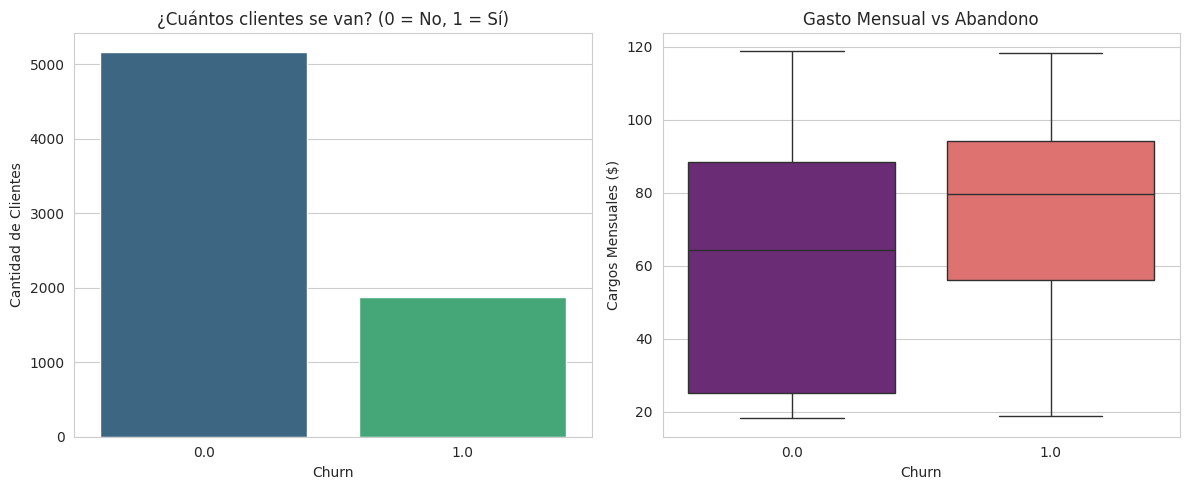


Resumen estadístico de los cargos mensuales:
        count       mean        std    min    25%    50%     75%     max
Churn                                                                   
0.0    5163.0  61.307408  31.094557  18.25  25.10  64.45  88.475  118.75
1.0    1869.0  74.441332  24.666053  18.85  56.15  79.65  94.200  118.35


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('¿Cuántos clientes se van? (0 = No, 1 = Sí)')
plt.xlabel('Churn')
plt.ylabel('Cantidad de Clientes')

plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='Monthly', data=df, palette='magma')
plt.title('Gasto Mensual vs Abandono')
plt.xlabel('Churn')
plt.ylabel('Cargos Mensuales ($)')

plt.tight_layout()
plt.show()

print("\nResumen estadístico de los cargos mensuales:")
print(df.groupby('Churn')['Monthly'].describe())

#📄Informe final

##  Conclusiones del Análisis de TelecomX

Luego de analizar 7,256 registros (después de eliminar los valores nulos en la columna Total), se pudieron identificar algunos aspectos importantes relacionados con la retención de clientes.

**Impacto del costo:** Uno de los puntos más claros es que los clientes con
cargos mensuales más altos tienden a cancelar el servicio con mayor frecuencia. En promedio, quienes abandonan la empresa pagan 74.44, mientras que los clientes que permanecen pagan alrededor de 61.30, lo que representa aproximadamente un 21 % más.

**Calidad de los datos:** Durante la limpieza de los datos se encontraron 11 registros con valores nulos en los cargos totales. Al revisarlos, se vio que correspondían a clientes nuevos con antigüedad de 0 meses, por lo que se manejaron de forma adecuada para que no afectaran el análisis.

**Estrategia recomendada:** A partir de estos resultados, sería recomendable revisar los planes de precios, especialmente los relacionados con fibra óptica y cargos adicionales. Los datos sugieren que los clientes con facturas más altas son quienes tienen más probabilidades de cancelar el servicio.

#Parte 2

---



In [4]:
columnas_interes = ['tenure', 'Monthly', 'Total', 'Churn']
df_modelo = df[columnas_interes].copy()

df_modelo.dropna(inplace=True)

X = df_modelo[['tenure', 'Monthly', 'Total']]
y = df_modelo['Churn']

print("Variables seleccionadas correctamente.")
X.head()

Variables seleccionadas correctamente.


,tenure,Monthly,Total
0,9,65.6,593.30
1,9,59.9,542.40
2,4,73.9,280.85
3,13,98.0,1237.85
4,3,83.9,267.40


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Datos de entrenamiento: {len(X_train)}")
print(f"Datos de prueba: {len(X_test)}")

Datos de entrenamiento: 4922
Datos de prueba: 2110


In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

predicciones = knn.predict(X_test)

print("¡Modelo entrenado y predicciones listas!")

¡Modelo entrenado y predicciones listas!


In [7]:
from sklearn.metrics import accuracy_score

exactitud = accuracy_score(y_test, predicciones)

print(f"La exactitud del modelo KNN es: {exactitud * 100:.2f}%")

La exactitud del modelo KNN es: 76.40%


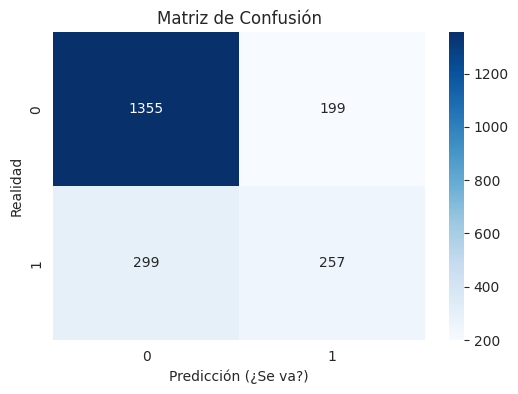

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

matriz = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción (¿Se va?)')
plt.ylabel('Realidad')
plt.show()

#Conclusiones

Para este desafío usamos el modelo de clasificación K-Nearest Neighbors (KNN) y obtuvimos algunos resultados interesantes.

El modelo alcanzó una exactitud del 76.40%, lo que quiere decir que acierta aproximadamente en tres de cada cuatro casos al predecir el comportamiento de los clientes.

Al revisar la matriz de confusión, se puede ver que el modelo identifica bastante bien a los clientes que deciden quedarse en la empresa. Esto es útil porque ayuda a entender qué características suelen tener los clientes más fieles.

Aun así, todavía hay margen de mejora. En esta versión del modelo hubo 299 casos en los que no se detectó que el cliente iba a irse. Para reducir este número en futuras versiones, sería buena idea incorporar más variables, por ejemplo el tipo de contrato o el servicio de internet que tiene cada cliente, ya que estos factores pueden influir en la decisión de permanecer o no en la empresa.

En general, el modelo ya puede servir como una herramienta de alerta temprana, ayudando al equipo de fidelización a identificar clientes con riesgo de irse y actuar a tiempo para retenerlos.